# Hierarchical RL: Options Framework

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand hierarchical RL concepts
- Implement options framework
- Build temporally extended actions
- Apply hierarchical RL to complex tasks

## 🔗 Prerequisites

- ✅ Understanding of RL fundamentals
- ✅ Understanding of policies
- ✅ Python knowledge

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 5**:
- Experimenting with hierarchical RL using options framework

---

## Introduction

**Hierarchical RL** uses temporal abstraction (options) to solve complex tasks by breaking them into subtasks, enabling faster learning and better generalization.

## Lesson Brief

This lesson introduces hierarchical RL through the idea of **options**, or reusable multi-step behaviors.

Students will see how a controller can make higher-level decisions instead of choosing every primitive action one by one.

Why this matters: hierarchical structure is useful when tasks are long, repetitive, or naturally broken into subgoals.

This lesson helps students think about abstraction in RL.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **Universitat Pompeu Fabra - Barcelona - "RLSS 2023: Hierarchical Reinforcement Learning"**:
[Watch on YouTube](https://www.youtube.com/watch?v=dooSrAH3o14)

Why this pick:
- Clear academic English and a theory-first explanation of hierarchy.
- Gives students a stronger overview of subtasks, abstraction, and long-horizon decomposition.
- Better fit for options-style thinking than a generic deep RL tutorial.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Hierarchy: solving with smaller sub-tasks.
- Option: a multi-step higher-level action.
- Subgoal: an intermediate target.
- Temporal abstraction: thinking beyond one step.
- High-level controller: chooses which option to run.

### Quick Check
- Why can hierarchy simplify a long task?
- What is the difference between an option and a primitive action?
- How do subgoals help sparse rewards?
- Why does temporal abstraction reduce decision burden?

### Common Mistakes
- Thinking hierarchy only adds complexity.
- Confusing options with ordinary actions.
- Missing the value of subgoals.
- Forgetting that the controller chooses options, while the option handles several primitive steps internally.


## Options Are Not Just Fancy Actions

A common student confusion is to hear the word option and think it is simply another action label.

### Primitive action

A primitive action is one immediate move, such as:

- step left
- step right
- open gripper

### Option

An option is a **temporally extended behavior**:

- it can start in some states
- it follows its own internal policy
- it stops when its termination condition is met

### Why this matters

The high-level controller does not micromanage every single step.
It chooses a reusable behavior, and that behavior runs for multiple time steps.

That is the real source of temporal abstraction.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np

# Show text or numbers in the cell output area under the code.
print("✅ Libraries imported!")
# Show text or numbers in the cell output area under the code.
print("\nHierarchical RL: Options Framework")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Show text or numbers in the cell output area under the code.
print("\nOptions Framework:")
# Show text or numbers in the cell output area under the code.
print("  - Option: Temporally extended action (policy + termination condition)")
# Show text or numbers in the cell output area under the code.
print("  - Initiation set: States where option can start")
# Show text or numbers in the cell output area under the code.
print("  - Policy: Option's internal policy")
# Show text or numbers in the cell output area under the code.
print("  - Termination: When option ends")

# Show text or numbers in the cell output area under the code.
print("\nBenefits:")
# Show text or numbers in the cell output area under the code.
print("  - Temporal abstraction")
# Show text or numbers in the cell output area under the code.
print("  - Faster learning")
# Show text or numbers in the cell output area under the code.
print("  - Better generalization")
# Show text or numbers in the cell output area under the code.
print("  - Reusable skills")

# Show text or numbers in the cell output area under the code.
print("\n✅ Hierarchical RL concepts understood!")


✅ Libraries imported!

Hierarchical RL: Options Framework

Options Framework:
  - Option: Temporally extended action (policy + termination condition)
  - Initiation set: States where option can start
  - Policy: Option's internal policy
  - Termination: When option ends

Benefits:
  - Temporal abstraction
  - Faster learning
  - Better generalization
  - Reusable skills

✅ Hierarchical RL concepts understood!


## Worked Example: Why Options Help in Long Tasks

Imagine a delivery robot moving through a building.

At the primitive-action level, the robot chooses one step at a time.
That works, but it makes planning slow because the agent must reason over many
small actions.

Hierarchical RL introduces **options** such as:
- `go_to_hallway`
- `move_to_goal_room`
- `approach_goal`

Each option is a small policy that lasts for several time steps.
The key idea is that the high-level controller chooses **which option to run**,
not every single movement step.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [2]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np

# A tiny map with two rooms connected by a hallway.
# The goal is to move from S to G.
# Save a value in a name so the next lines can read it.
LAYOUT = ["S", ".", ".", "H", ".", ".", "G"]
# Another assignment—same idea: store a value for the lines below.
START = 0
# Another assignment—same idea: store a value for the lines below.
GOAL = len(LAYOUT) - 1


# Function `primitive_step` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: state, action.
def primitive_step(state, action):
    # If the condition is True, run the indented block under this line.
    if action == "right":
        # Send a value back to whoever called this function.
        return min(state + 1, GOAL)
    # If the condition is True, run the indented block under this line.
    if action == "left":
        # Send a value back to whoever called this function.
        return max(state - 1, 0)
    # Explicitly raise an error to signal invalid state or failed checks.
    raise ValueError("Unknown action")


# Function `option_go_to_hallway` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: state.
def option_go_to_hallway(state):
    # Save a value in a name so the next lines can read it.
    trajectory = [state]
    # Start a loop: repeat the indented block while the condition stays True.
    while state < 3:
        # Create or choose a variable used in the Bellman warm-up demo.
        state = primitive_step(state, "right")
        # Add one new item to the end of a list (the list grows in place).
        trajectory.append(state)
    # Send a value back to whoever called this function.
    return state, trajectory


# Function `option_go_to_goal` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: state.
def option_go_to_goal(state):
    # Save a value in a name so the next lines can read it.
    trajectory = [state]
    # Start a loop: repeat the indented block while the condition stays True.
    while state < GOAL:
        # Create or choose a variable used in the Bellman warm-up demo.
        state = primitive_step(state, "right")
        # Add one new item to the end of a list (the list grows in place).
        trajectory.append(state)
    # Send a value back to whoever called this function.
    return state, trajectory


# Primitive plan: one action at a time.
# Save a value in a name so the next lines can read it.
primitive_state = START
# Another assignment—same idea: store a value for the lines below.
primitive_trajectory = [primitive_state]
# Another assignment—same idea: store a value for the lines below.
primitive_actions = []
# Start a loop: repeat the indented block while the condition stays True.
while primitive_state != GOAL:
    # Save a value in a name so the next lines can read it.
    primitive_state = primitive_step(primitive_state, "right")
    # Add one new item to the end of a list (the list grows in place).
    primitive_actions.append("right")
    # Add one new item to the end of a list (the list grows in place).
    primitive_trajectory.append(primitive_state)

# Hierarchical plan: choose options instead of individual actions.
# Save a value in a name so the next lines can read it.
option_state = START
# Another assignment—same idea: store a value for the lines below.
chosen_options = []
# Another assignment—same idea: store a value for the lines below.
option_trajectory = [option_state]

# Another assignment—same idea: store a value for the lines below.
option_state, path1 = option_go_to_hallway(option_state)
# Add one new item to the end of a list (the list grows in place).
chosen_options.append("go_to_hallway")
# Execute: option_trajectory.extend(path1[1:])
option_trajectory.extend(path1[1:])

# Save a value in a name so the next lines can read it.
option_state, path2 = option_go_to_goal(option_state)
# Add one new item to the end of a list (the list grows in place).
chosen_options.append("go_to_goal")
# Execute: option_trajectory.extend(path2[1:])
option_trajectory.extend(path2[1:])

# Show text or numbers in the cell output area under the code.
print("Map:", " ".join(LAYOUT))
# Show text or numbers in the cell output area under the code.
print("\nPrimitive trajectory:", primitive_trajectory)
# Show text or numbers in the cell output area under the code.
print("Primitive actions used:", len(primitive_actions))
# Show text or numbers in the cell output area under the code.
print("Primitive controller decisions:", primitive_actions)

# Show text or numbers in the cell output area under the code.
print("\nOption trajectory:", option_trajectory)
# Show text or numbers in the cell output area under the code.
print("High-level decisions used:", len(chosen_options))
# Show text or numbers in the cell output area under the code.
print("Chosen options:", chosen_options)

# Show text or numbers in the cell output area under the code.
print("\nTeaching point:")
# Show text or numbers in the cell output area under the code.
print("Both approaches reach the same goal, but the hierarchical controller makes")
# Show text or numbers in the cell output area under the code.
print("fewer high-level decisions because each option covers several primitive steps.")


Map: S . . H . . G

Primitive trajectory: [0, 1, 2, 3, 4, 5, 6]
Primitive actions used: 6
Primitive controller decisions: ['right', 'right', 'right', 'right', 'right', 'right']

Option trajectory: [0, 1, 2, 3, 4, 5, 6]
High-level decisions used: 2
Chosen options: ['go_to_hallway', 'go_to_goal']

Teaching point:
Both approaches reach the same goal, but the hierarchical controller makes
fewer high-level decisions because each option covers several primitive steps.


In [3]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Sutton, R. S., Precup, D. & Singh, S. (1999). *Between MDPs and Semi-MDPs: A Framework for Temporal Abstraction in Reinforcement Learning* (the options framework). Artificial Intelligence, 112, 181-211.
2. Bacon, P.-L., Harb, J. & Precup, D. (2017). *The Option-Critic Architecture*. AAAI. <https://arxiv.org/abs/1609.05140>
3. Murphy, K. (2024). *Reinforcement Learning: An Overview*. arXiv:2412.05265. <https://arxiv.org/abs/2412.05265>
"""))

## 📚 References

1. Sutton, R. S., Precup, D. & Singh, S. (1999). *Between MDPs and Semi-MDPs: A Framework for Temporal Abstraction in Reinforcement Learning* (the options framework). Artificial Intelligence, 112, 181-211.
2. Bacon, P.-L., Harb, J. & Precup, D. (2017). *The Option-Critic Architecture*. AAAI. <https://arxiv.org/abs/1609.05140>
3. Murphy, K. (2024). *Reinforcement Learning: An Overview*. arXiv:2412.05265. <https://arxiv.org/abs/2412.05265>


## Summary

This notebook introduced the main intuition behind hierarchical RL:

- primitive actions control the environment step by step
- **options** are reusable multi-step behaviors
- the high-level controller selects options, not every individual move

### Why this matters

Hierarchical structure becomes useful when tasks are long, repetitive, or have
natural subgoals such as hallways, rooms, checkpoints, or pickup locations.

### What to remember

If a task can be broken into meaningful sub-skills, hierarchical RL can make
learning and planning easier to manage.

### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


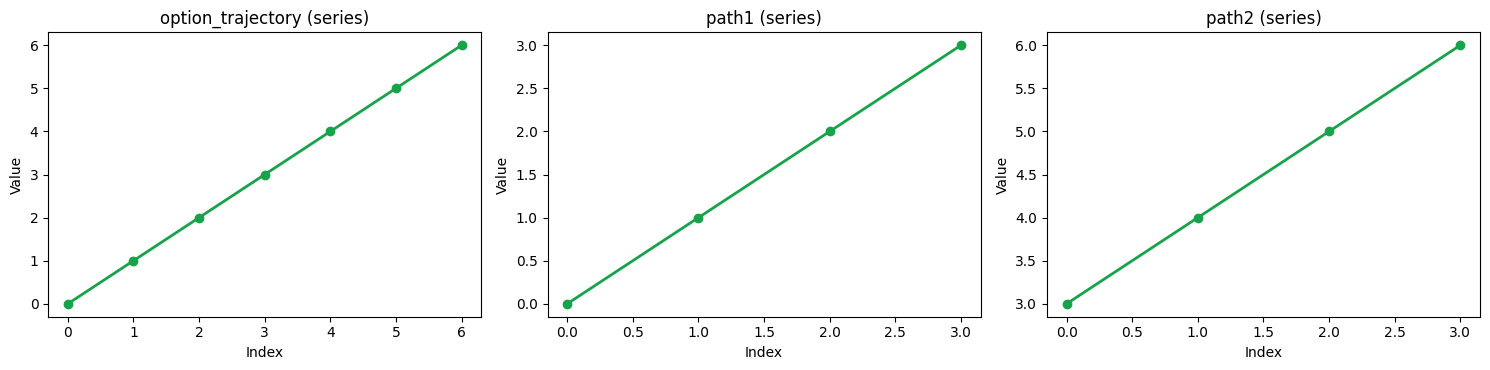

In [4]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Hierarchical RL breaks long tasks into reusable sub-skills so the agent can reason at more than one level of abstraction.

**If students remember one idea:** Options are useful because real tasks often need meaningful intermediate behaviors, not only one-step decisions.

**Quick check before moving on:**
- Can you explain how an option differs from a single primitive action?
- Can you describe why hierarchy can help with long-horizon problems?

**Bridge to the next step:** The next lesson changes perspective again by learning a model of the world and planning with it.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=10 | term=True | trunc=False


objc[14558]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x113ed4138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1143d09c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[14558]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x113ed4188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1143d0a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[14558]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x113ed3c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1143d0a68). T

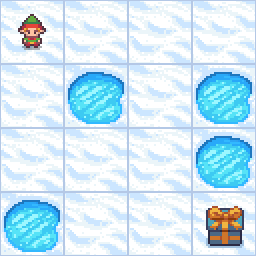

In [5]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
